In [4]:
import pandas as pd
import numpy as np


data = pd.read_csv("B_practice.csv")
data.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [5]:
# modeling 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from scipy.stats import randint

import seaborn as sns
import matplotlib.pyplot as plt 


# Tree Visualization 
from sklearn.tree import export_graphviz
from IPython.display import Image

In [6]:
X = data.drop(columns=["ID", "ZIP Code", "Personal Loan"])

y = data["Personal Loan"]

In [8]:
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

y_pred = rf.predict(X_test)




In [9]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 11)
Testing data: (1000, 11)


In [10]:
print("Accuracy Score : ",round(accuracy_score(y_test,y_pred),4)*100)
print("Precision Score : ",round(precision_score(y_test,y_pred),4)*100)
print("Recall Score : ",round(recall_score(y_test,y_pred),4)*100)
print("F1 Score : ",round(f1_score(y_test,y_pred),4)*100)




Accuracy Score :  99.2
Precision Score :  97.83
Recall Score :  93.75
F1 Score :  95.74000000000001


In [11]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[902   2]
 [  6  90]]


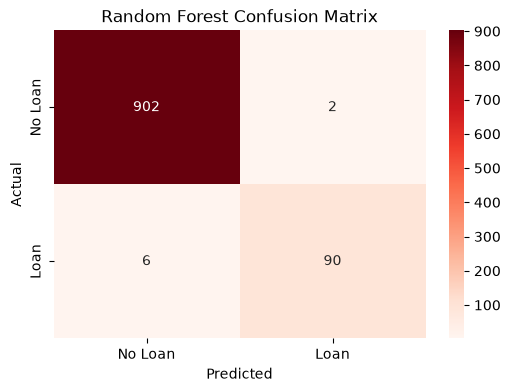

In [12]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["No Loan", "Loan"],
    yticklabels=["No Loan", "Loan"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

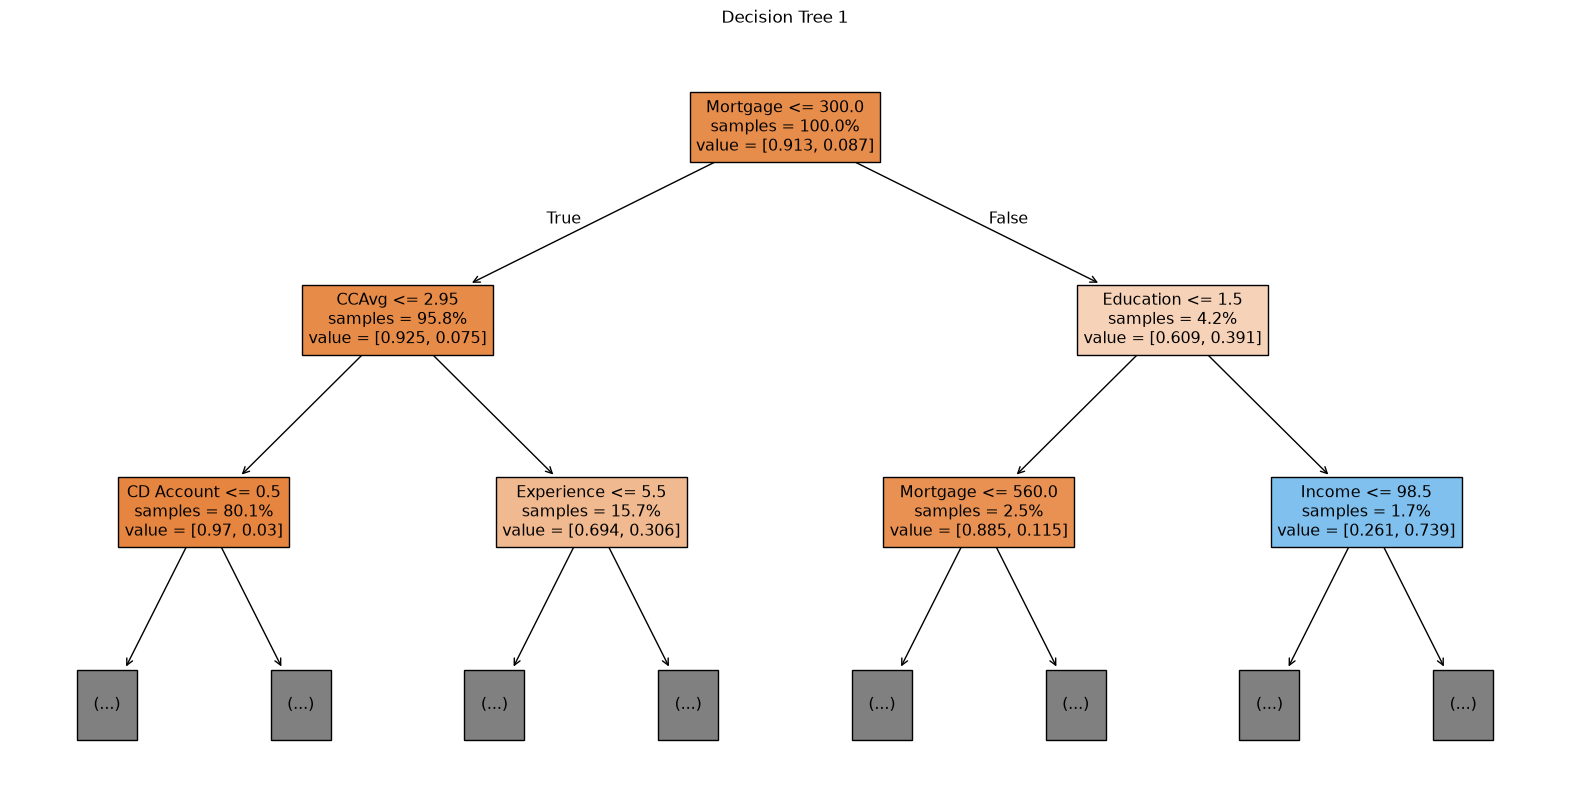

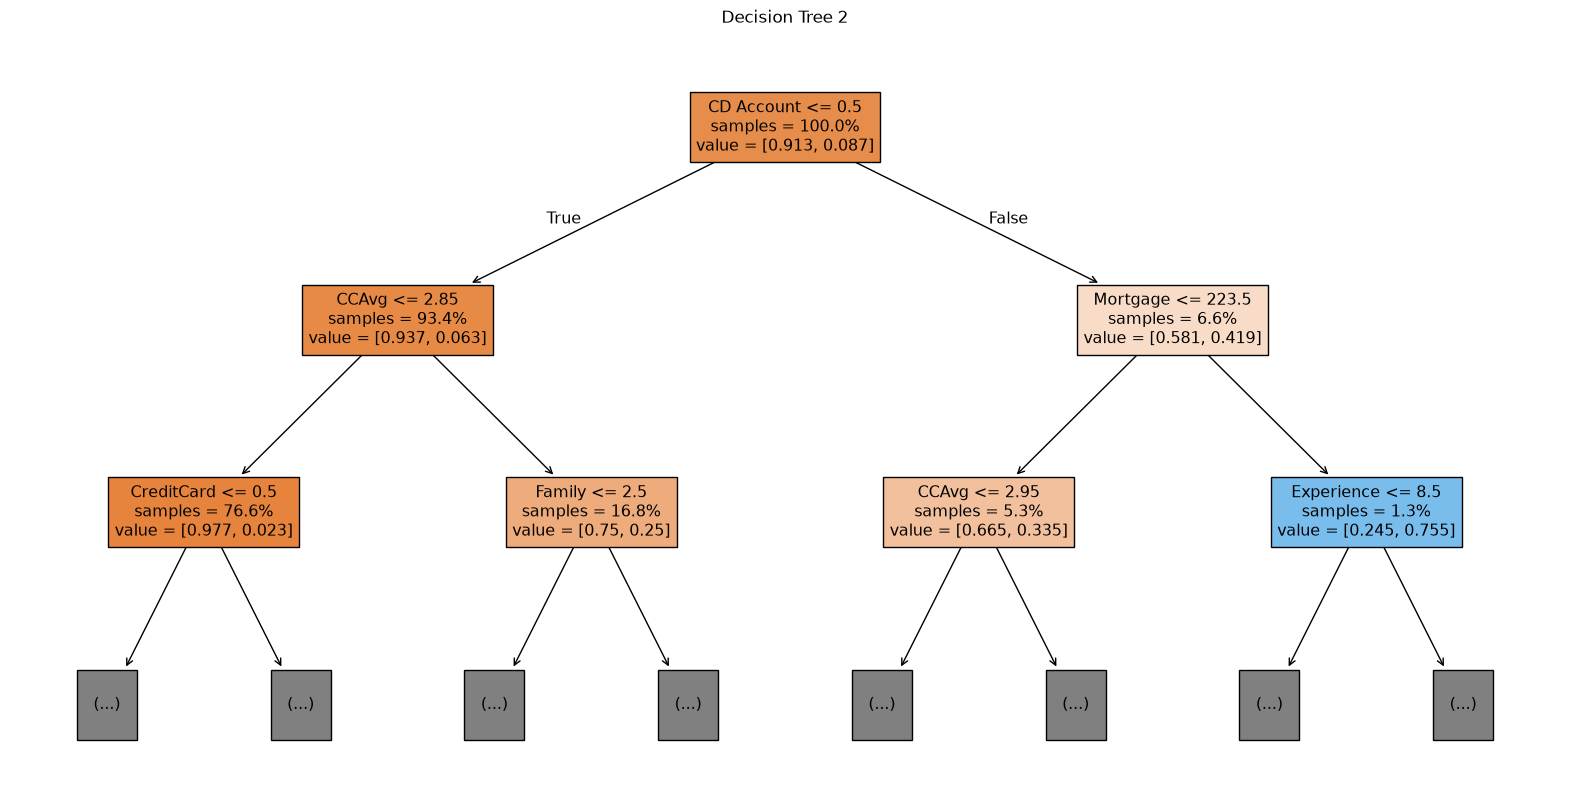

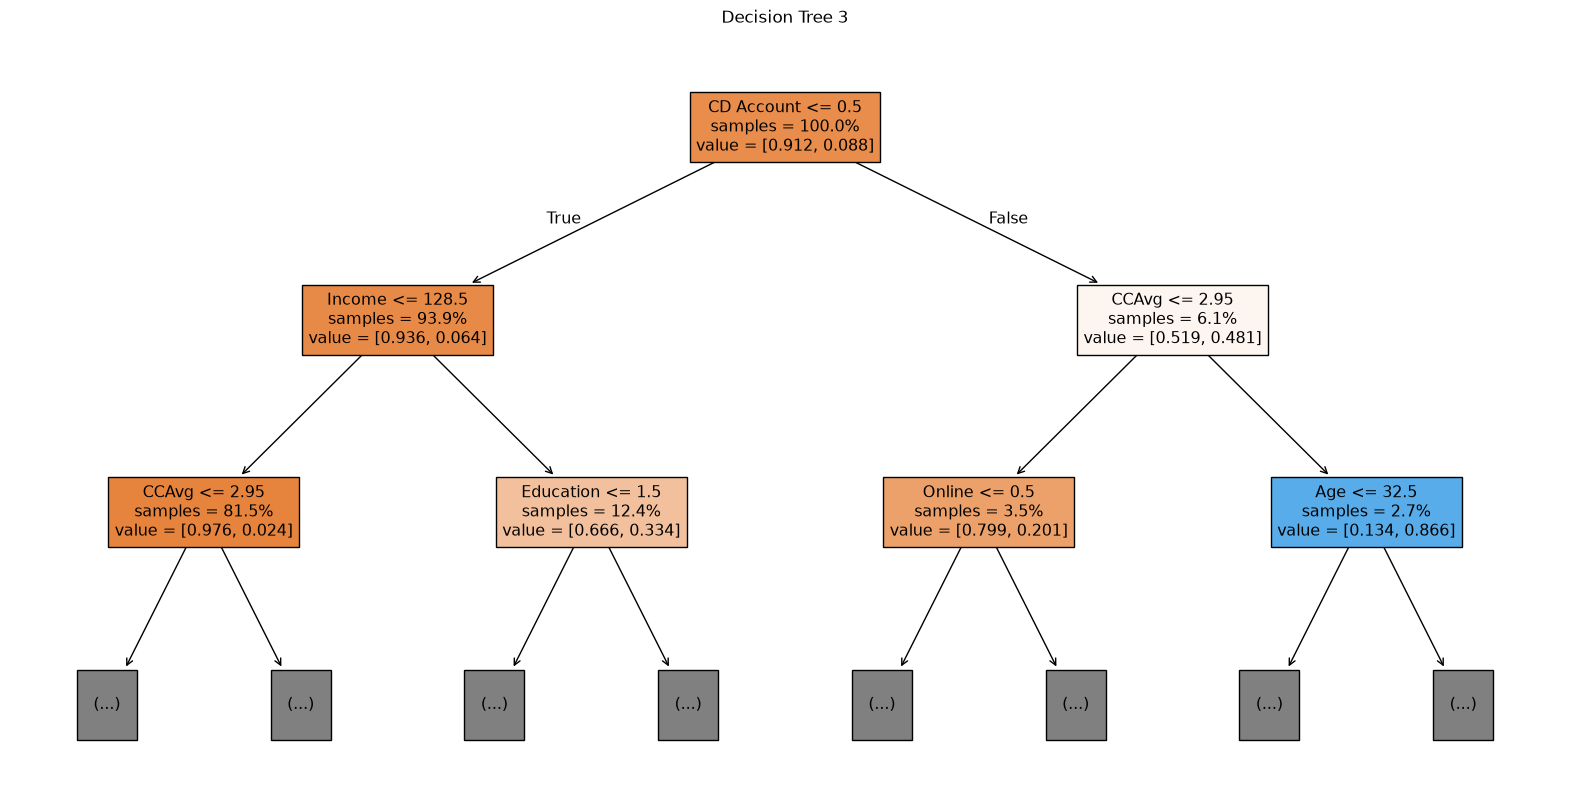

In [13]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

for i in range(3):
    tree = rf.estimators_[i]

    plt.figure(figsize=(20,10))

    plot_tree(
        tree,
        feature_names=X_train.columns,
        filled=True,
        max_depth=2,
        impurity=False,
        proportion=True
    )

    plt.title(f"Decision Tree {i+1}")
    plt.show()